focus on the areawith type , additionalroom , age possession , furniture deatiels, features 

In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)    
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('data_gurgaon_properties_cleaned_v1.csv')

In [4]:
df.duplicated().sum()

0

In [5]:
df.head(1)

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features
0,3 BHK Flat in Sector 65 Gurgaon,flat,m3m golfestate,sector 65,4.94,16233.0,3043.0,Super Built up area 3043(282.7 sq.m.),3,4,3,Servant Room,"Tower, Sector 65 Gurgaon, Gurgaon, Haryana",15.0,North-East,5 to 10 Year Old,"['Sector 54 Chowk Metro Station', 'Sahara Mall', 'NH 248A', 'Shiksha Bharti Public School', 'Gurugram University', 'Park Hospital', 'Indira Gandhi International Airport', 'Garhi Harsaru Junction', 'Holiday Inn Express Gurugram']","M3m golfestate in sector 65, gurgaon is a ready-To-Move housing society. It offers apartments and studio apartments in varied budget range. These units are a perfect combination of comfort and style, specifically designed to suit your requirements and conveniences. There are 1bhk, 2bhk, 3bhk, 4bhk and 5bhk apartments and 1rk studio apartments available in this project. This housing society is now ready to be called home as families have started moving in. Check out some of the features of m3m golfestate housing society:*m3m golfestate sector 65 has 25 towers, with 40 floors each and 870 units on offer.*spread over an area of 56 acres, m3m golfestate is one of the spacious housing societies in the gurgaon region. With all the basic amenities available, m3m golfestate fits into your budget and your lifestyle.*sector 65 has good connectivity to some of the important areas in the proximity such as sapphire mall sector 49, golf course extension road and skyjumper trampoline park gurgaon and so on.\n Additional details :The apartment has munciple supply water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nNo power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.",[],"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [6]:
df.sample(5)[['price', 'area' , 'areaWithType']]

,price,area,areaWithType
2328,2.30,2300.00,Carpet area: 2290 (212.75 sq.m.)
1759,8.50,3238.76,Plot area 360(301.01 sq.m.)
1702,4.60,1732.36,Plot area 192(160.54 sq.m.)
932,0.71,1439.00,Carpet area: 1436 (133.41 sq.m.)
2499,1.65,2100.00,Super Built up area 2100(195.1 sq.m.)Carpet area: 1720 sq.ft. (159.79 sq.m.)


In [7]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [10]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [11]:
df[['price','type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
150,0.90,flat,1690.0,Built Up area: 1690 (157.01 sq.m.),NaN,1690.00,NaN
3400,0.82,flat,1523.0,Super Built up area 1523(141.49 sq.m.)Built Up area: 1221.18 sq.ft. (113.45 sq.m.),1523.0,1221.18,NaN
1438,0.49,flat,596.0,Super Built up area 602(55.93 sq.m.)Built Up area: 598 sq.ft. (55.56 sq.m.),602.0,598.00,NaN
2818,4.50,house,1345.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
1233,3.05,flat,1875.0,Super Built up area 2385(221.57 sq.m.)Built Up area: 2200 sq.ft. (204.39 sq.m.)Carpet area: 1875 sq.ft. (174.19 sq.m.),2385.0,2200.00,1875.0


In [12]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(531, 7)

In [13]:
df[df['areaWithType'].str.contains('Plot')][['price','type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.45,house,2883.68,Plot area 320(267.56 sq.m.),NaN,NaN,NaN
17,6.25,house,27889.92,Plot area 3100(2591.99 sq.m.)Built Up area: 2660 sq.yards (2224.1 sq.m.)Carpet area: 2500 sq.yards (2090.32 sq.m.),NaN,2660.0,2500.0
19,7.20,house,4519.20,Plot area 420,NaN,NaN,NaN
40,3.50,house,1441.84,Plot area 1440(133.78 sq.m.),NaN,NaN,NaN
49,2.50,house,1904.52,Plot area 1900(176.52 sq.m.),NaN,NaN,NaN


In [14]:
df.isnull().sum()

property_name             0
type                      0
society                 482
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom         1507
address                   9
floorNum                 19
facing                    0
agePossession             1
nearbyLocations         169
description               0
furnishDetails          941
features                593
super_built_up_area    1787
built_up_area          2520
carpet_area            1792
dtype: int64

In [15]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [16]:
all_nan_df.head()

,price,type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.45,house,2883.68,Plot area 320(267.56 sq.m.),NaN,NaN,NaN
19,7.20,house,4519.20,Plot area 420,NaN,NaN,NaN
40,3.50,house,1441.84,Plot area 1440(133.78 sq.m.),NaN,NaN,NaN
49,2.50,house,1904.52,Plot area 1900(176.52 sq.m.),NaN,NaN,NaN
59,4.35,house,1345.00,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [17]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [18]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [19]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [20]:
all_nan_df.head(6)

,price,type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.45,house,2883.68,Plot area 320(267.56 sq.m.),NaN,320.0,NaN
19,7.20,house,4519.20,Plot area 420,NaN,420.0,NaN
40,3.50,house,1441.84,Plot area 1440(133.78 sq.m.),NaN,1440.0,NaN
49,2.50,house,1904.52,Plot area 1900(176.52 sq.m.),NaN,1900.0,NaN
59,4.35,house,1345.00,Plot area 150(125.42 sq.m.),NaN,150.0,NaN
68,4.15,house,2248.84,Plot area 250(209.03 sq.m.),NaN,250.0,NaN


In [21]:
# update the original dataframe
df.update(all_nan_df)

In [22]:
# Additional room 
df['additionalRoom'].value_counts() 

additionalRoom
Servant Room                                     687
Study Room                                       242
Others                                           219
Pooja Room                                       164
Store Room                                        97
Study Room,Servant Room                           96
Pooja Room,Servant Room                           82
Pooja Room,Study Room,Servant Room,Store Room     71
Servant Room,Others                               55
Pooja Room,Study Room,Servant Room                52
Pooja Room,Study Room,Servant Room,Others         51
Servant Room,Pooja Room                           38
Servant Room,Store Room                           30
Study Room,Others                                 26
Pooja Room,Study Room                             21
Pooja Room,Others                                 16
Pooja Room,Store Room                             15
Servant Room,Study Room                           12
Study Room,Servant Room,Store R

In [23]:
df['additionalRoom'].fillna('Not available' , inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7208\3850683312.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['additionalRoom'].fillna('Not available' , inplace=True)


In [24]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.lower().str.contains(col).astype(int)

In [25]:
df['additionalRoom'].isnull().sum()

0

In [26]:
df.sample(5)[['additionalRoom', 'study room', 'servant room', 'store room', 'pooja room', 'others' ]]

,additionalRoom,study room,servant room,store room,pooja room,others
3052,Not available,0,0,0,0,0
753,"Servant Room,Store Room",0,1,1,0,0
98,Not available,0,0,0,0,0
3643,"Servant Room,Study Room,Others",1,1,0,0,1
1773,"Study Room,Others",1,0,0,0,1


In [27]:
# Age possession 
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1640
5 to 10 Year Old       557
0 to 1 Year Old        500
undefined              306
10+ Year Old           301
Under Construction      87
Within 6 months         67
Within 3 months         24
Dec-23                  18
By 2023                 17
By 2024                 16
Dec-24                  14
Mar-24                  12
Dec-25                   7
Aug-23                   6
Jan-24                   6
Jun-24                   5
Nov-23                   5
Oct-24                   5
Aug-24                   4
Sep-23                   4
By 2025                  4
Oct-23                   3
May-24                   3
Feb-24                   3
Jan-25                   3
Jul-24                   3
Nov-24                   3
Jun-27                   2
Dec 2023                 2
Dec-26                   2
Jun 2024                 2
Aug-25                   2
By 2027                  2
Jan-26                   2
Jul-25                   2
Mar-25        

In [28]:
df['agePossession']

0         5 to 10 Year Old
1         5 to 10 Year Old
2          1 to 5 Year Old
3                undefined
4          1 to 5 Year Old
5          1 to 5 Year Old
6          Within 6 months
7          0 to 1 Year Old
8          1 to 5 Year Old
9         5 to 10 Year Old
10         Within 3 months
11         0 to 1 Year Old
12         1 to 5 Year Old
13        5 to 10 Year Old
14         0 to 1 Year Old
15               undefined
16         1 to 5 Year Old
17         0 to 1 Year Old
18         1 to 5 Year Old
19            10+ Year Old
20         1 to 5 Year Old
21         1 to 5 Year Old
22         1 to 5 Year Old
23         0 to 1 Year Old
24         1 to 5 Year Old
25         1 to 5 Year Old
26         1 to 5 Year Old
27         1 to 5 Year Old
28                  May-24
29               undefined
30         1 to 5 Year Old
31         1 to 5 Year Old
32               undefined
33      Under Construction
34        5 to 10 Year Old
35         0 to 1 Year Old
36            10+ Year Old
3

In [29]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [30]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [31]:
df['agePossession'].value_counts()

agePossession
Relatively New        1640
New Property           591
Moderately Old         557
Undefined              439
Old Property           301
Under Construction     134
Name: count, dtype: int64

In [32]:
# 4. furnished details 
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3591,[],NaN
1101,"['8 Fan', '1 Exhaust Fan', '4 Geyser', '1 Stove', '12 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1345,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN
2447,[],"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting', 'Water softening plant']"
3116,"['3 Wardrobe', '9 Fan', '1 Exhaust Fan', '3 Geyser', '11 Light', '1 Modular Kitchen', '3 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [33]:
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

In [34]:
all_furnishings

['',
 '3 Wardrobe',
 '4 Fan',
 '1 Geyser',
 '5 Light',
 '1 Modular Kitchen',
 'No AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Washing Machine',
 'No Water Purifier',
 '10 Light',
 '4 AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Modular Kitchen',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Wardrobe',
 'No Washing Machine',
 'No Water Purifier',
 '1 Light',
 '1 AC',
 '1 Modular Kitchen',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Fan',
 'No Geyser',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Wardrobe',
 'No Washing Machine',
 'No Water Purifier',
 '4 Fan',
 '4 Light',
 '1 Modular Kitchen',
 'No AC',
 'No Bed',
 'No Chimney',
 'No Curtains',
 'No Dining Table',
 'No Exhaust Fan',
 'No Geyser',
 'No Microwave',
 

In [35]:
import re

In [36]:
# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7208\1034340008.py:6: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [37]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7208\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [38]:
furnishings_df.isnull().sum()

Geyser             0
Modular Kitchen    0
Sofa               0
Light              0
Exhaust Fan        0
Fan                0
Stove              0
Wardrobe           0
Dining Table       0
Curtains           0
AC                 0
TV                 0
Bed                0
Washing Machine    0
Chimney            0
Water Purifier     0
Fridge             0
Microwave          0
dtype: int64

In [39]:
furnishings_df.shape

(3662, 18)

In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [42]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

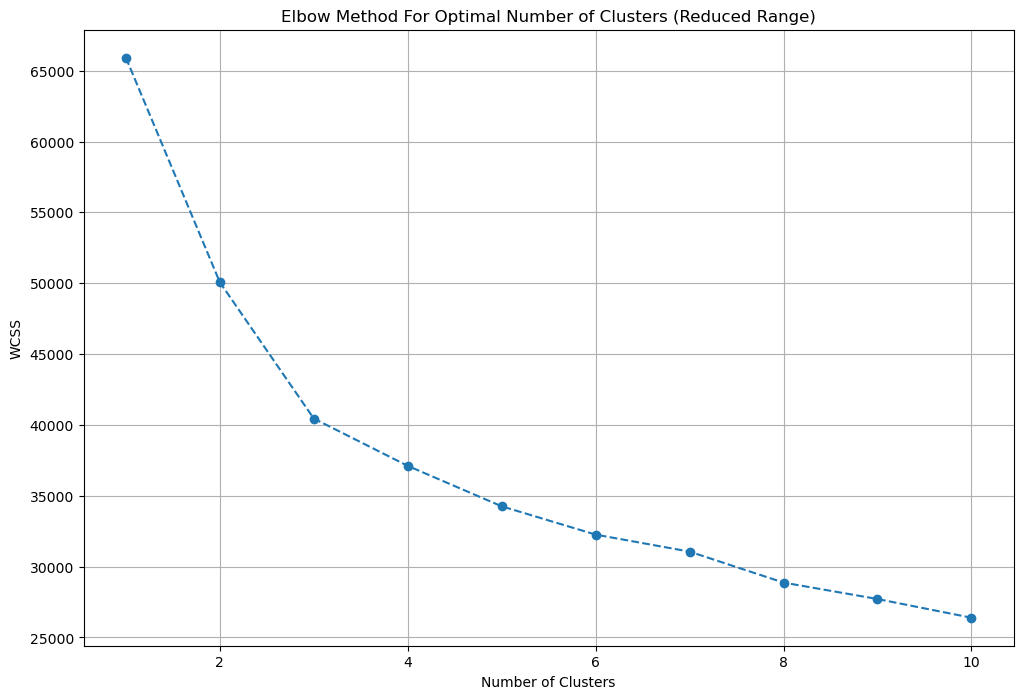

In [43]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [45]:
df = df.iloc[:,:-18]

In [46]:
df['furnishing_type'] = cluster_assignments

In [50]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> semifurnished
# 1 -> unfurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1401,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",1
3522,"['3 Wardrobe', '1 Exhaust Fan', '1 Geyser', '7 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1115,"['5 Fan', '1 Exhaust Fan', '4 Geyser', '21 Light', '1 Chimney', '1 Modular Kitchen', '4 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
1756,"['6 Fan', '1 Exhaust Fan', '3 Geyser', '6 Light', '3 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3104,[],1


In [52]:
df.shape

(3662, 29)

In [53]:
df[['society','features']].sample(5)


,society,features
2452,m3m woodshire,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
257,NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
2272,international city by sobha phase 1,"['Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Separate entry for servant room', 'Park', 'Visitor Parking', 'Security Personnel', 'Fitness Centre / GYM', 'Club house / Community Center']"
2583,emaar mgf marbella,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
2960,NaN,['Park']


In [54]:
df['features'].isnull().sum()

593

In [58]:
df['society'].value_counts()

society
tulip violet                                         75
ss the leaf                                          73
shapoorji pallonji joyville gurugram                 42
dlf new town heights                                 42
signature global park                                35
shree vardhman victoria                              34
smart world orchard                                  33
emaar mgf emerald floors premier                     32
paras dews                                           31
dlf the ultima                                       31
dlf regal gardens                                    30
m3m woodshire                                        30
shree vardhman flora                                 29
la vida by tata housing                              28
smart world gems                                     28
signature global solera                              27
godrej nature plus                                   27
bptp terra                              

In [59]:
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [60]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [61]:
temp_df = df[df['features'].isnull()]

In [62]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [64]:
df.loc[temp_df.index,'features'] = x.values

In [65]:
df['features'].isnull().sum()

452

In [66]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [67]:
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [68]:
features_binary_df.sample(10)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1361,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2682,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
1810,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0
3605,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
812,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
3100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0

In [69]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [70]:
df['luxury_score'] = luxury_score

In [71]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [72]:
df.to_csv('data_gurgaon_properties_cleaned_v2.csv',index=False)